# Text-Conditioned MIDI Fine-Tuning

This notebook fine-tunes the existing MIDI decoder with natural-language prompts using cross-attention.

It now reads the dataset directly from Hugging Face MIDI-CAPS instead of requiring a local JSONL file.

The code auto-detects the text and MIDI columns from the dataset and converts each MIDI example into event tokens using the existing tokenizer.

The notebook keeps the current MIDI tokenizer and pretrained decoder weights, and only adds text conditioning modules.

In [1]:
import shutil
shutil.copytree("/kaggle/input/datasets/bhaskarpandey42/gg111111/transformer", "/kaggle/working/transformer", dirs_exist_ok=True)

'/kaggle/working/transformer'

In [2]:
import os
import sys
from pathlib import Path
import torch

PROJECT_DIR = Path("/kaggle/working/transformer")
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

print('Project directory:', PROJECT_DIR)
print('CUDA available:', torch.cuda.is_available())
print('GPU count:', torch.cuda.device_count())

Project directory: /kaggle/working/transformer
CUDA available: True
GPU count: 2


In [3]:
# Runtime / configuration
import torch
from pathlib import Path

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Model / training hyperparameters
VOCAB_SIZE = 2199
D_MODEL = 640
NUM_HEADS = 10
NUM_LAYERS = 10
D_FF = 2048
MAX_SEQ_LEN = 1024
SEQ_LEN = 256
BATCH_SIZE = 8
EPOCHS = 3
LR = 1e-4
DROPOUT = 0.1

# Text encoder / prompt settings
TEXT_ENCODER_NAME = "BAAI/bge-base-en-v1.5"
TEXT_ENCODER_TRAIN_BASE = False
MAX_TEXT_LEN = 64

# MIDI tokenizer settings
MAX_TIME_SHIFT = 16
NUM_VELOCITY_BUCKETS = 16
TOKEN_WINDOW_STRIDE = 128

# Hugging Face dataset settings
HF_DATASET_CANDIDATES = ["amaai-lab/MidiCaps"]
HF_SPLIT = "train"
HF_STREAMING = False
HF_LIMIT = 2000
HF_MIDI_ROOT = None

# Checkpoints (use Path so .exists() works)
CHECKPOINT_PATH = Path("/kaggle/input/datasets/bhaskarpandey42/model112/phase2_best_text_conditioned.pt")
CHECKPOINT_DIR = Path("/kaggle/working/checkpoints_text_conditioned")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

print("Config cell initialized. DEVICE:", DEVICE, "HF_LIMIT:", HF_LIMIT, "TOKEN_WINDOW_STRIDE:", TOKEN_WINDOW_STRIDE)


Config cell initialized. DEVICE: cuda HF_LIMIT: 2000 TOKEN_WINDOW_STRIDE: 128


In [4]:
from transformers import AutoModel, AutoTokenizer
from torch import nn

TEXT_TOKENIZER = AutoTokenizer.from_pretrained(TEXT_ENCODER_NAME)
if TEXT_TOKENIZER.pad_token is None:
    TEXT_TOKENIZER.pad_token = TEXT_TOKENIZER.eos_token or TEXT_TOKENIZER.sep_token or TEXT_TOKENIZER.unk_token

base_text_encoder = AutoModel.from_pretrained(TEXT_ENCODER_NAME)


def encode_prompt_batch(prompts, max_len: int = MAX_TEXT_LEN):
    encoded = TEXT_TOKENIZER(
        list(prompts),
        padding=True,
        truncation=True,
        max_length=max_len,
        return_tensors="pt",
    )
    return encoded["input_ids"], encoded["attention_mask"]


class PretrainedPromptEncoder(nn.Module):
    def __init__(self, encoder: nn.Module, output_size: int, dropout: float = 0.1):
        super().__init__()
        self.encoder = encoder
        hidden_size = getattr(self.encoder.config, "hidden_size", None)
        if hidden_size is None:
            raise ValueError("Text encoder must expose a hidden_size in its config")
        self.projection = nn.Linear(hidden_size, output_size)
        self.dropout = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(output_size)

    def forward(self, input_ids: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        hidden = self.dropout(outputs.last_hidden_state)
        projected = self.projection(hidden)
        return self.layer_norm(projected)

print("Loaded text tokenizer and encoder base:", TEXT_ENCODER_NAME)


config.json:   0%|          | 0.00/777 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-base-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded text tokenizer and encoder base: BAAI/bge-base-en-v1.5


In [5]:
# Build / load MIDI model with cross-attention (must run before training cell)
from conditional_transformer import build_conditional_model, load_partial_checkpoint

model = build_conditional_model(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    d_ff=D_FF,
    max_seq_len=MAX_SEQ_LEN,
    dropout=DROPOUT,
    device=DEVICE,
    context_hidden_size=D_MODEL,
)

# Optional: load MIDI checkpoint if available
if CHECKPOINT_PATH.exists():
    info = load_partial_checkpoint(model, str(CHECKPOINT_PATH), map_location=DEVICE)
    print("Loaded MIDI checkpoint partially:", info)
else:
    print(f"Checkpoint not found: {CHECKPOINT_PATH}. Training MIDI side from scratch.")

model.to(DEVICE)
model.train()


Loaded MIDI checkpoint partially: {'loaded_key_count': 0, 'skipped_key_count': 266, 'skipped_keys': ['module.decoder.layers.0.self_attention.w_q.weight', 'module.decoder.layers.0.self_attention.w_q.bias', 'module.decoder.layers.0.self_attention.w_k.weight', 'module.decoder.layers.0.self_attention.w_k.bias', 'module.decoder.layers.0.self_attention.w_v.weight', 'module.decoder.layers.0.self_attention.w_v.bias', 'module.decoder.layers.0.self_attention.w_o.weight', 'module.decoder.layers.0.self_attention.w_o.bias', 'module.decoder.layers.0.cross_attention.w_q.weight', 'module.decoder.layers.0.cross_attention.w_q.bias', 'module.decoder.layers.0.cross_attention.w_k.weight', 'module.decoder.layers.0.cross_attention.w_k.bias', 'module.decoder.layers.0.cross_attention.w_v.weight', 'module.decoder.layers.0.cross_attention.w_v.bias', 'module.decoder.layers.0.cross_attention.w_o.weight', 'module.decoder.layers.0.cross_attention.w_o.bias', 'module.decoder.layers.0.feed_forward.linear1.weight', 'mod

ConditionalGPTmini(
  (decoder): Decoder(
    (layers): ModuleList(
      (0-9): 10 x DecoderLayer(
        (self_attention): MultiHeadAttention(
          (w_q): Linear(in_features=640, out_features=640, bias=True)
          (w_k): Linear(in_features=640, out_features=640, bias=True)
          (w_v): Linear(in_features=640, out_features=640, bias=True)
          (w_o): Linear(in_features=640, out_features=640, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (cross_attention): MultiHeadAttention(
          (w_q): Linear(in_features=640, out_features=640, bias=True)
          (w_k): Linear(in_features=640, out_features=640, bias=True)
          (w_v): Linear(in_features=640, out_features=640, bias=True)
          (w_o): Linear(in_features=640, out_features=640, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (feed_forward): FeedForward(
          (linear1): Linear(in_features=640, out_features=2048, bias=True)
          (dr

In [6]:
import json
import re
from pathlib import Path
from typing import List, Optional
from pathlib import Path
import tarfile

import requests

import torch
from torch.nn.utils.rnn import pad_sequence
import torch.nn.functional as F

from midi_tokenizer import (
    midi_file_to_event_tokens,
    encode_tokens_to_ids,
    load_vocab,
    build_fixed_midi_vocab,
    save_vocab,
)
from huggingface_hub import hf_hub_url, hf_hub_download


DATASET_REPO_ID = "amaai-lab/MidiCaps"
MIDICAPS_CACHE_DIR = Path('/kaggle/working/midicaps_cache')
MIDICAPS_CACHE_DIR.mkdir(parents=True, exist_ok=True)
MIDICAPS_TAR_PATH = Path(
    hf_hub_download(
        repo_id=DATASET_REPO_ID,
        filename='midicaps.tar.gz',
        repo_type='dataset',
    )
)
MIDICAPS_TAR = None

candidate_vocab_paths = [
    Path("/kaggle/working/data/midi_vocab_fixed.json"),
    Path("data/midi_vocab_fixed.json"),
]
MIDI_VOCAB_PATH = next((p for p in candidate_vocab_paths if p.exists()), None)
if MIDI_VOCAB_PATH is None:
    MIDI_VOCAB_PATH = Path("/kaggle/working/data/midi_vocab_fixed.json")
    MIDI_VOCAB_PATH.parent.mkdir(parents=True, exist_ok=True)
    vocab = build_fixed_midi_vocab(
        max_time_shift=MAX_TIME_SHIFT,
        num_velocity_buckets=NUM_VELOCITY_BUCKETS,
    )
    save_vocab(vocab, MIDI_VOCAB_PATH)
    print(f"Created MIDI vocab at {MIDI_VOCAB_PATH}")

MIDI_VOCAB = load_vocab(MIDI_VOCAB_PATH)
VOCAB_SIZE = len(MIDI_VOCAB)
print(f"Loaded MIDI vocab with {VOCAB_SIZE} tokens from {MIDI_VOCAB_PATH}")
if 'model' in globals():
    embedding = getattr(getattr(model, 'token_embed', None), 'embedding', None)
    if embedding is not None and embedding.num_embeddings != VOCAB_SIZE:
        print(
            'Vocab size changed; rerun Cell 6 to rebuild the model with VOCAB_SIZE='
        )


def _candidate_location_names(location_value: str) -> list[str]:
    normalized = location_value.replace('\\', '/').lstrip('./')
    return [
        normalized,
        location_value,
        normalized.replace('midicaps/', ''),
        normalized.replace('lmd_full/', 'midicaps/lmd_full/'),
        Path(normalized).name,
    ]



def _open_midicaps_tar():
    global MIDICAPS_TAR
    if MIDICAPS_TAR is None:
        MIDICAPS_TAR = tarfile.open(MIDICAPS_TAR_PATH, mode='r:gz')
    return MIDICAPS_TAR



def _reset_midicaps_tar_stream():
    global MIDICAPS_TAR
    if MIDICAPS_TAR is not None:
        try:
            MIDICAPS_TAR.close()
        except Exception:
            pass
    MIDICAPS_TAR = None



def _extract_from_stream(location_value: str) -> Path | None:
    candidate_names = _candidate_location_names(location_value)
    tar = _open_midicaps_tar()

    for candidate in candidate_names:
        try:
            member = tar.getmember(candidate)
        except KeyError:
            continue

        safe_name = member.name.replace('/', '__').replace('\\', '__')
        extracted_path = MIDICAPS_CACHE_DIR / safe_name
        if not extracted_path.exists():
            extracted_path.parent.mkdir(parents=True, exist_ok=True)
            source = tar.extractfile(member)
            if source is None:
                return None
            extracted_path.write_bytes(source.read())
        return extracted_path

    for member in tar.getmembers():
        member_name = member.name.replace('\\', '/')
        if not any(member_name == candidate or member_name.endswith('/' + candidate) for candidate in candidate_names):
            continue

        safe_name = member_name.replace('/', '__').replace('\\', '__')
        extracted_path = MIDICAPS_CACHE_DIR / safe_name
        if not extracted_path.exists():
            extracted_path.parent.mkdir(parents=True, exist_ok=True)
            source = tar.extractfile(member)
            if source is None:
                return None
            extracted_path.write_bytes(source.read())
        return extracted_path

    return None



def resolve_location_to_midi_path(location_value: str, dataset, midi_root: str | None) -> Path:
    loc = Path(location_value)

    if loc.exists():
        return loc

    if midi_root:
        candidate = Path(midi_root) / location_value
        if candidate.exists():
            return candidate

    extracted_path = _extract_from_stream(location_value)
    if extracted_path is not None:
        return extracted_path

    _reset_midicaps_tar_stream()
    extracted_path = _extract_from_stream(location_value)
    if extracted_path is not None:
        return extracted_path

    raise FileNotFoundError(f"Could not resolve '{location_value}' from the MidiCaps tar archive.")



def _make_token_windows(tokens: torch.Tensor, seq_len: int, stride: int) -> list[torch.Tensor]:
    max_window_length = seq_len + 1
    if tokens.numel() < 2:
        return []

    if stride <= 0:
        stride = max(1, seq_len // 2)

    windows: list[torch.Tensor] = []
    last_start = max(0, tokens.numel() - max_window_length)
    seen_starts = set()

    for start in range(0, max(1, tokens.numel() - 1), stride):
        if start > last_start:
            start = last_start
        if start in seen_starts:
            continue
        seen_starts.add(start)
        chunk = tokens[start:start + max_window_length]
        if chunk.numel() >= 2:
            windows.append(chunk)
        if start == last_start:
            break

    if last_start not in seen_starts:
        tail_chunk = tokens[last_start:last_start + max_window_length]
        if tail_chunk.numel() >= 2:
            windows.append(tail_chunk)

    return windows



def build_captioned_midi_rows(
    dataset,
    midi_root: str | None = None,
    limit: int | None = None,
    log_every: int = 25,
    seq_len: int = SEQ_LEN,
    stride: int = TOKEN_WINDOW_STRIDE,
):
    rows = []
    total = limit if limit is not None else 50
    print(f"Preparing caption/MIDI rows from up to {total} examples with seq_len={seq_len}, stride={stride}...")

    skipped_missing = 0
    skipped_short = 0
    skipped_error = 0
    added_windows = 0

    for index, example in enumerate(dataset):
        if index >= total:
            break

        caption = example.get("caption")
        location = example.get("location")
        if caption is None or location is None:
            skipped_missing += 1
            continue

        try:
            midi_path = resolve_location_to_midi_path(str(location), dataset, midi_root)
            tokens = midi_file_to_event_tokens(
                midi_path,
                grid_ticks=120,
                max_time_shift=MAX_TIME_SHIFT,
                num_velocity_buckets=NUM_VELOCITY_BUCKETS,
            )
            token_ids = encode_tokens_to_ids(tokens, MIDI_VOCAB)
            tokens = torch.tensor(token_ids, dtype=torch.long)
        except Exception as exc:
            skipped_error += 1
            if skipped_error <= 3:
                print(f"skip index={index} location={location!s} error={exc}")
            continue

        windows = _make_token_windows(tokens, seq_len=seq_len, stride=stride)
        if not windows:
            skipped_short += 1
            continue

        for window in windows:
            rows.append({"caption": str(caption), "tokens": window, "location": str(location)})
        added_windows += len(windows)

        if (index + 1) % log_every == 0:
            print(
                f"processed={index + 1}/{total} rows={len(rows)} windows_added={added_windows} ",
                f"skipped_missing={skipped_missing} skipped_short={skipped_short} skipped_error={skipped_error}"
            )

    if not rows:
        raise ValueError("No usable caption/MIDI pairs were produced from MIDI-CAPS")

    print(
        f"Done. rows={len(rows)} windows_added={added_windows} skipped_missing={skipped_missing} ",
        f"skipped_short={skipped_short} skipped_error={skipped_error}"
    )
    return rows



def collate_captioned_batch(batch, seq_len: int):
    captions, token_lists = zip(*batch)
    input_ids, attention_mask = encode_prompt_batch(list(captions), max_len=MAX_TEXT_LEN)

    x_list = []
    y_list = []
    for tokens in token_lists:
        if tokens.numel() < 2:
            continue
        chunk = tokens[: seq_len + 1]
        if chunk.numel() < 2:
            continue
        x = chunk[:-1]
        y = chunk[1:]
        if x.numel() == 0 or y.numel() == 0:
            continue
        x_list.append(x)
        y_list.append(y)

    if not x_list:
        raise ValueError("Batch did not contain any usable sequences")

    x_padded = pad_sequence(x_list, batch_first=True, padding_value=0)
    y_padded = pad_sequence(y_list, batch_first=True, padding_value=0)

    if x_padded.size(1) < seq_len:
        pad_len = seq_len - x_padded.size(1)
        x_padded = F.pad(x_padded, (0, pad_len), value=0)
        y_padded = F.pad(y_padded, (0, pad_len), value=0)
    else:
        x_padded = x_padded[:, :seq_len]
        y_padded = y_padded[:, :seq_len]

    text = {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
    }
    return text, x_padded, y_padded

midicaps.tar.gz:   0%|          | 0.00/1.62G [00:00<?, ?B/s]

Created MIDI vocab at /kaggle/working/data/midi_vocab_fixed.json
Loaded MIDI vocab with 2199 tokens from /kaggle/working/data/midi_vocab_fixed.json


In [7]:
# Extract MidiCaps once to avoid tar scanning on every lookup
EXTRACT_ROOT = Path("/kaggle/working/midicaps_extracted")
EXTRACT_MARKER = EXTRACT_ROOT / ".extracted"

if not EXTRACT_MARKER.exists():
    EXTRACT_ROOT.mkdir(parents=True, exist_ok=True)
    with tarfile.open(MIDICAPS_TAR_PATH, mode="r:gz") as tar:
        for member in tar.getmembers():
            member_path = (EXTRACT_ROOT / member.name).resolve()
            if not str(member_path).startswith(str(EXTRACT_ROOT.resolve())):
                raise ValueError(f"Unsafe path in tar file: {member.name}")
        tar.extractall(EXTRACT_ROOT)
    EXTRACT_MARKER.write_text("ok", encoding="utf-8")
    print(f"Extracted MidiCaps to {EXTRACT_ROOT}")
else:
    print(f"MidiCaps already extracted at {EXTRACT_ROOT}")

HF_MIDI_ROOT = str(EXTRACT_ROOT)
print(f"HF_MIDI_ROOT set to {HF_MIDI_ROOT}")

/tmp/ipykernel_57/361632054.py:12: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(EXTRACT_ROOT)


Extracted MidiCaps to /kaggle/working/midicaps_extracted
HF_MIDI_ROOT set to /kaggle/working/midicaps_extracted


In [8]:
# Instantiate pretrained text encoder
from torch import nn

text_encoder: nn.Module = PretrainedPromptEncoder(base_text_encoder, output_size=D_MODEL, dropout=DROPOUT)
text_encoder = text_encoder.to(DEVICE)

if not TEXT_ENCODER_TRAIN_BASE:
    for param in text_encoder.encoder.parameters():
        param.requires_grad = False

trainable_base = any(p.requires_grad for p in text_encoder.encoder.parameters())
print(f"Using pretrained text encoder: {TEXT_ENCODER_NAME}")
print(f"Base text encoder trainable: {trainable_base}")


Using pretrained text encoder: BAAI/bge-base-en-v1.5
Base text encoder trainable: False


## MIDI-CAPS schema used here

This notebook assumes the dataset rows look like your screenshot:
- `caption`: natural language description
- `location`: MIDI path (often relative, e.g. `lmd_full/...mid`)

Path resolution order:
1. Use `location` directly if it exists on disk.
2. If `HF_MIDI_ROOT` is set, try `HF_MIDI_ROOT / location`.
3. Try resolving from Hugging Face dataset cache directories.

If none of these work, set `HF_MIDI_ROOT` to your downloaded MIDI-CAPS root folder.

In [9]:
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
from conditional_transformer import freeze_module

raw_dataset = None
last_error = None
for candidate in HF_DATASET_CANDIDATES:
    try:
        raw_dataset = load_dataset(candidate, split=HF_SPLIT, streaming=HF_STREAMING)
        HF_DATASET_NAME = candidate
        print(f"Loaded dataset: {candidate}")
        break
    except Exception as exc:
        last_error = exc
        print(f"Could not load dataset {candidate}: {exc}")

if raw_dataset is None:
    raise last_error

if HF_STREAMING:
    preview = next(iter(raw_dataset.take(1)))
    column_names = list(preview.keys())
else:
    column_names = raw_dataset.column_names
print("Dataset columns:", column_names)
required = {"caption", "location"}
missing = sorted(required - set(column_names))
if missing:
    raise ValueError(f"MIDI-CAPS split is missing required columns: {missing}")

if HF_LIMIT is None:
    HF_LIMIT = 2000
    print(f"HF_LIMIT was None, using starter limit HF_LIMIT={HF_LIMIT}")
else:
    print(f"Using HF_LIMIT={HF_LIMIT}")

captioned_rows = build_captioned_midi_rows(
    raw_dataset,
    midi_root=HF_MIDI_ROOT,
    limit=HF_LIMIT,
    log_every=100,
)
print(f"Prepared {len(captioned_rows)} caption/MIDI pairs")

class CaptionedMidiDataset(Dataset):
    def __init__(self, rows):
        self.rows = rows

    def __len__(self) -> int:
        return len(self.rows)

    def __getitem__(self, idx: int):
        row = self.rows[idx]
        tokens = row["tokens"]
        if isinstance(tokens, torch.Tensor):
            return row["caption"], tokens
        return row["caption"], torch.tensor(tokens, dtype=torch.long)


dataset = CaptionedMidiDataset(captioned_rows)
loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=False,
    collate_fn=lambda batch: collate_captioned_batch(batch, SEQ_LEN),
)

if len(loader) == 0:
    raise ValueError(
        "DataLoader has zero batches. Lower SEQ_LEN, lower BATCH_SIZE, or raise HF_LIMIT."
    )

print(f"DataLoader batches per epoch: {len(loader)}")

if DEVICE.type == "cuda" and torch.cuda.device_count() > 1:
    model = torch.nn.DataParallel(model)
    print(f"Using DataParallel on {torch.cuda.device_count()} GPUs")

base_model = model.module if hasattr(model, "module") else model

optimizer = torch.optim.AdamW(
    list(p for p in model.parameters() if p.requires_grad) + list(text_encoder.parameters()),
    lr=LR,
)
criterion = nn.NLLLoss()

# Checkpointing config
CHECKPOINT_DIR = Path("/kaggle/working/checkpoints_text_conditioned")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
LAST_CKPT = Path("/kaggle/input/datasets/bhaskarpandey42/model112/phase2_best_text_conditioned.pt")
BEST_CKPT = CHECKPOINT_DIR / "best_text_conditioned.pt"

best_train_loss = float("inf")
start_epoch = 1

# Optional resume if a previous checkpoint exists
if LAST_CKPT.exists():
    ckpt = torch.load(LAST_CKPT, map_location=DEVICE)
    base_model.load_state_dict(ckpt["model_state_dict"], strict=False)
    if "text_encoder_state_dict" in ckpt:
        text_encoder.load_state_dict(ckpt["text_encoder_state_dict"], strict=True)
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    start_epoch = int(ckpt.get("epoch", 0)) + 1
    best_train_loss = float(ckpt.get("best_train_loss", float("inf")))
    print(f"Resumed from {LAST_CKPT} at epoch {start_epoch}")

# Warm start: train cross-attention and text projection first.
for layer in base_model.decoder.layers:
    if hasattr(layer, "self_attention"):
        freeze_module(layer.self_attention)
    if hasattr(layer, "feed_forward"):
        freeze_module(layer.feed_forward)

LOG_EVERY_STEPS = 25
for epoch in range(start_epoch, EPOCHS + 1):
    model.train()
    text_encoder.train()
    running = 0.0
    running_count = 0
    epoch_loss_sum = 0.0
    epoch_batches = 0

    for batch_idx, (text_batch, x, y) in enumerate(loader, start=1):
        x = x.to(DEVICE)
        y = y.to(DEVICE)
        text_batch = {k: v.to(DEVICE) for k, v in text_batch.items()}

        optimizer.zero_grad(set_to_none=True)
        context = text_encoder(text_batch["input_ids"], text_batch["attention_mask"])
        context_mask = text_batch["attention_mask"].unsqueeze(1).unsqueeze(1)
        log_probs = model(x, context=context, context_mask=context_mask)
        loss = criterion(log_probs.view(-1, log_probs.size(-1)), y.view(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(list(model.parameters()) + list(text_encoder.parameters()), 1.0)
        optimizer.step()

        loss_value = float(loss.item())
        running += loss_value
        running_count += 1
        epoch_loss_sum += loss_value
        epoch_batches += 1

        if batch_idx % LOG_EVERY_STEPS == 0:
            print(
                f"epoch={epoch} step={batch_idx}/{len(loader)} "
                f"loss={running / max(1, running_count):.4f}"
            )
            running = 0.0
            running_count = 0

    if running_count > 0:
        print(
            f"epoch={epoch} step={epoch_batches}/{len(loader)} "
            f"loss={running / running_count:.4f}"
        )

    epoch_train_loss = epoch_loss_sum / max(1, epoch_batches)
    print(f"finished epoch {epoch} | train_loss={epoch_train_loss:.4f}")

    checkpoint = {
        "epoch": epoch,
        "model_state_dict": base_model.state_dict(),
        "text_encoder_state_dict": text_encoder.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "train_loss": epoch_train_loss,
        "best_train_loss": min(best_train_loss, epoch_train_loss),
        "config": {
            "hf_dataset_name": HF_DATASET_NAME,
            "hf_split": HF_SPLIT,
            "max_time_shift": MAX_TIME_SHIFT,
            "num_velocity_buckets": NUM_VELOCITY_BUCKETS,
            "seq_len": SEQ_LEN,
            "batch_size": BATCH_SIZE,
            "learning_rate": LR,
            "epochs": EPOCHS,
            "hf_limit": HF_LIMIT,
        },
    }

    torch.save(checkpoint, LAST_CKPT)
    print(f"Saved last checkpoint: {LAST_CKPT}")

    if epoch_train_loss < best_train_loss:
        best_train_loss = epoch_train_loss
        torch.save(checkpoint, BEST_CKPT)
        print(f"Saved new best checkpoint: {BEST_CKPT}")

README.md: 0.00B [00:00, ?B/s]

train.json:   0%|          | 0.00/428M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/168385 [00:00<?, ? examples/s]

Loaded dataset: amaai-lab/MidiCaps
Dataset columns: ['location', 'caption', 'genre', 'genre_prob', 'mood', 'mood_prob', 'key', 'time_signature', 'tempo', 'tempo_word', 'duration', 'duration_word', 'chord_summary', 'chord_summary_occurence', 'instrument_summary', 'instrument_numbers_sorted', 'all_chords', 'all_chords_timestamps', 'test_set']
Using HF_LIMIT=2000
Preparing caption/MIDI rows from up to 2000 examples with seq_len=256, stride=128...
processed=100/2000 rows=11219 windows_added=11219  skipped_missing=0 skipped_short=0 skipped_error=0
processed=200/2000 rows=21174 windows_added=21174  skipped_missing=0 skipped_short=0 skipped_error=0
processed=300/2000 rows=31438 windows_added=31438  skipped_missing=0 skipped_short=0 skipped_error=0
processed=400/2000 rows=44823 windows_added=44823  skipped_missing=0 skipped_short=0 skipped_error=0
skip index=423 location=lmd_full/1/152891ac63017b234c33e75e4a4a28c5.mid error=index out of range
processed=500/2000 rows=56352 windows_added=56352  

KeyboardInterrupt: 

In [32]:
from pathlib import Path
import shutil

src = Path("/kaggle/working/checkpoints_text_conditioned/best_text_conditioned.pt")
zip_path = Path("/kaggle/working/best_checkpoint.zip")

if not src.exists():
    raise FileNotFoundError(f"Not found: {src}")

shutil.make_archive("/kaggle/working/best_checkpoint", "zip", root_dir=src.parent, base_dir=src.name)
print("Created:", zip_path)

Created: /kaggle/working/best_checkpoint.zip


In [34]:
# Phase 2: unfreeze decoder backbone and continue fine-tuning at lower LR with checkpointing.
from conditional_transformer import unfreeze_module

base_model = model.module if hasattr(model, "module") else model

for layer in base_model.decoder.layers:
    if hasattr(layer, "self_attention"):
        unfreeze_module(layer.self_attention)
    if hasattr(layer, "feed_forward"):
        unfreeze_module(layer.feed_forward)

In [39]:
from pathlib import Path
import shutil

src = Path("/kaggle/working/checkpoints_text_conditioned/phase2_best_text_conditioned.pt")
zip_path = Path("/kaggle/working/phase2best_checkpoint.zip")

if not src.exists():
    raise FileNotFoundError(f"Not found: {src}")

shutil.make_archive("/kaggle/working/phase2best_checkpoint", "zip", root_dir=src.parent, base_dir=src.name)
print("Created:", zip_path)

Created: /kaggle/working/phase2best_checkpoint.zip


In [38]:
PHASE2_EPOCHS = 4
PHASE2_LR = 2e-5
PHASE2_PLATEAU_PATIENCE = 2
PHASE2_PLATEAU_FACTOR = 0.5
PHASE2_MIN_LR = 5e-6

optimizer = torch.optim.AdamW(
    list(model.parameters()) + list(text_encoder.parameters()),
    lr=PHASE2_LR,
 )

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=PHASE2_PLATEAU_FACTOR,
    patience=PHASE2_PLATEAU_PATIENCE,
    min_lr=PHASE2_MIN_LR,
    verbose=True,
 )

PHASE2_LAST_CKPT = CHECKPOINT_DIR / "phase2_last_text_conditioned.pt"
PHASE2_BEST_CKPT = CHECKPOINT_DIR / "phase2_best_text_conditioned.pt"
phase2_best_train_loss = float("inf")
phase2_start_epoch = 1

# Optional resume for phase 2
if PHASE2_LAST_CKPT.exists():
    ckpt = torch.load(PHASE2_LAST_CKPT, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state_dict"], strict=False)
    if "text_encoder_state_dict" in ckpt:
        text_encoder.load_state_dict(ckpt["text_encoder_state_dict"], strict=True)
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    if "scheduler_state_dict" in ckpt:
        scheduler.load_state_dict(ckpt["scheduler_state_dict"])
    phase2_start_epoch = int(ckpt.get("epoch", 0)) + 1
    phase2_best_train_loss = float(ckpt.get("best_train_loss", float("inf")))
    print(f"Resumed phase 2 from {PHASE2_LAST_CKPT} at epoch {phase2_start_epoch}")
else:
    # If phase 2 starts fresh, initialize from best phase 1 checkpoint when available.
    if BEST_CKPT.exists():
        ckpt = torch.load(BEST_CKPT, map_location=DEVICE)
        model.load_state_dict(ckpt["model_state_dict"], strict=False)
        if "text_encoder_state_dict" in ckpt:
            text_encoder.load_state_dict(ckpt["text_encoder_state_dict"], strict=True)
        print(f"Initialized phase 2 from phase 1 best checkpoint: {BEST_CKPT}")

for epoch in range(phase2_start_epoch, PHASE2_EPOCHS + 1):
    model.train()
    text_encoder.train()
    running = 0.0
    epoch_loss_sum = 0.0
    epoch_batches = 0

    for batch_idx, (text_batch, x, y) in enumerate(loader, start=1):
        x = x.to(DEVICE)
        y = y.to(DEVICE)
        text_batch = {k: v.to(DEVICE) for k, v in text_batch.items()}

        optimizer.zero_grad(set_to_none=True)
        context = text_encoder(text_batch["input_ids"], text_batch["attention_mask"] )
        context_mask = text_batch["attention_mask"].unsqueeze(1).unsqueeze(1)
        log_probs = model(x, context=context, context_mask=context_mask)
        loss = criterion(log_probs.view(-1, log_probs.size(-1)), y.view(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(list(model.parameters()) + list(text_encoder.parameters()), 1.0)
        optimizer.step()

        loss_value = float(loss.item())
        running += loss_value
        epoch_loss_sum += loss_value
        epoch_batches += 1

        if batch_idx % 25 == 0:
            current_lr = optimizer.param_groups[0]["lr"]
            print(f"phase2 epoch={epoch} step={batch_idx} loss={running/25:.4f} lr={current_lr:.2e}")
            running = 0.0

    epoch_train_loss = epoch_loss_sum / max(1, epoch_batches)
    scheduler.step(epoch_train_loss)
    print(f"phase2 finished epoch {epoch} | train_loss={epoch_train_loss:.4f}")

    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "text_encoder_state_dict": text_encoder.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "train_loss": epoch_train_loss,
        "best_train_loss": min(phase2_best_train_loss, epoch_train_loss),
        "config": {
            "phase": 2,
            "hf_dataset_name": HF_DATASET_NAME,
            "hf_split": HF_SPLIT,
            "max_time_shift": MAX_TIME_SHIFT,
            "num_velocity_buckets": NUM_VELOCITY_BUCKETS,
            "seq_len": SEQ_LEN,
            "batch_size": BATCH_SIZE,
            "learning_rate": PHASE2_LR,
            "epochs": PHASE2_EPOCHS,
            "plateau_factor": PHASE2_PLATEAU_FACTOR,
            "plateau_patience": PHASE2_PLATEAU_PATIENCE,
            "min_lr": PHASE2_MIN_LR,
        },
    }

    torch.save(checkpoint, PHASE2_LAST_CKPT)
    print(f"Saved phase2 last checkpoint: {PHASE2_LAST_CKPT}")

    if epoch_train_loss < phase2_best_train_loss:
        phase2_best_train_loss = epoch_train_loss
        torch.save(checkpoint, PHASE2_BEST_CKPT)
        print(f"Saved phase2 best checkpoint: {PHASE2_BEST_CKPT}")

print("Phase 2 complete. Use PHASE2_BEST_CKPT for generation.")

Initialized phase 2 from phase 1 best checkpoint: /kaggle/working/checkpoints_text_conditioned/best_text_conditioned.pt
phase2 epoch=1 step=25 loss=2.1711 lr=2.00e-05
phase2 epoch=1 step=50 loss=2.0697 lr=2.00e-05
phase2 epoch=1 step=75 loss=2.0961 lr=2.00e-05
phase2 epoch=1 step=100 loss=2.0458 lr=2.00e-05
phase2 epoch=1 step=125 loss=2.0977 lr=2.00e-05
phase2 epoch=1 step=150 loss=2.2075 lr=2.00e-05
phase2 epoch=1 step=175 loss=2.0974 lr=2.00e-05
phase2 epoch=1 step=200 loss=2.0104 lr=2.00e-05
phase2 epoch=1 step=225 loss=2.0826 lr=2.00e-05
phase2 epoch=1 step=250 loss=2.1007 lr=2.00e-05
phase2 epoch=1 step=275 loss=2.0659 lr=2.00e-05
phase2 epoch=1 step=300 loss=2.0787 lr=2.00e-05
phase2 epoch=1 step=325 loss=2.1612 lr=2.00e-05
phase2 epoch=1 step=350 loss=2.1442 lr=2.00e-05
phase2 epoch=1 step=375 loss=2.2235 lr=2.00e-05
phase2 epoch=1 step=400 loss=2.0678 lr=2.00e-05
phase2 epoch=1 step=425 loss=2.0314 lr=2.00e-05
phase2 epoch=1 step=450 loss=2.1725 lr=2.00e-05
phase2 epoch=1 step

KeyboardInterrupt: 

Loaded checkpoint: /kaggle/working/checkpoints_text_conditioned/phase2_best_text_conditioned.pt


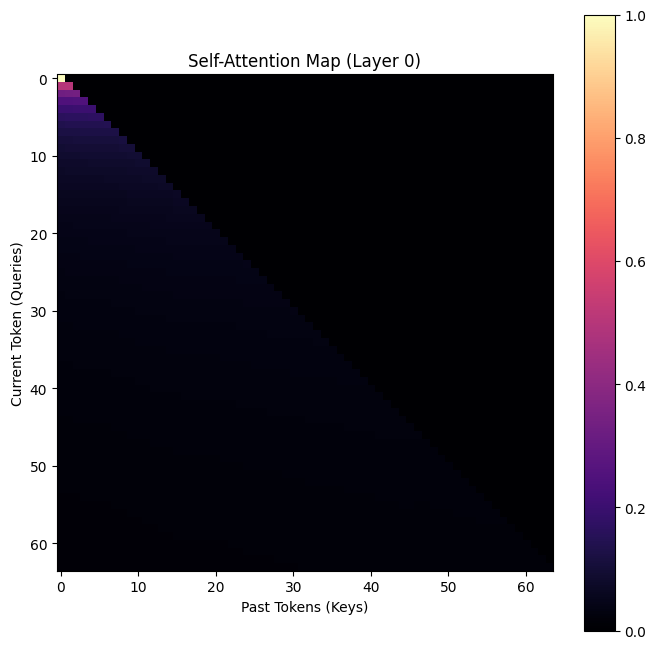

In [89]:
# Sample prompt + one forward pass to visualize self-attention
import matplotlib.pyplot as plt

prompt = "rock music"
seq_len_plot = 64
layer_idx = 0

base_model = model.module if hasattr(model, "module") else model
ckpt_path = None
if "PHASE2_BEST_CKPT" in globals() and PHASE2_BEST_CKPT.exists():
    ckpt_path = PHASE2_BEST_CKPT
elif "BEST_CKPT" in globals() and BEST_CKPT.exists():
    ckpt_path = BEST_CKPT
if ckpt_path is None:
    raise FileNotFoundError("No checkpoint found for attention map visualization.")
ckpt = torch.load(ckpt_path, map_location=DEVICE)
base_model.load_state_dict(ckpt["model_state_dict"], strict=False)
if "text_encoder_state_dict" in ckpt:
    text_encoder.load_state_dict(ckpt["text_encoder_state_dict"], strict=True)
print(f"Loaded checkpoint: {ckpt_path}")

base_model.eval()
text_encoder.eval()

if "loader" in globals():
    text_batch, x, _ = next(iter(loader))
    tokens = x[:1, :seq_len_plot]
else:
    tokens = torch.randint(0, VOCAB_SIZE, (1, seq_len_plot))

tokens = tokens.to(DEVICE)
input_ids, attention_mask = encode_prompt_batch([prompt], max_len=MAX_TEXT_LEN)
input_ids = input_ids.to(DEVICE)
attention_mask = attention_mask.to(DEVICE)

with torch.no_grad():
    context = text_encoder(input_ids, attention_mask)
    context_mask = attention_mask.unsqueeze(1).unsqueeze(1)
    _ = base_model(tokens, context=context, context_mask=context_mask)

attn = base_model.decoder.layers[layer_idx].self_attention.attention_scores
attn_avg = attn.mean(dim=1)[0].detach().cpu().numpy()

plt.figure(figsize=(8, 8))
plt.imshow(attn_avg, cmap="magma")
plt.title(f"Self-Attention Map (Layer {layer_idx})")
plt.xlabel("Past Tokens (Keys)")
plt.ylabel("Current Token (Queries)")
plt.colorbar()
plt.show()

In [45]:
import time
from IPython.display import Audio, display

from midi_tokenizer import (
    TIME_SHIFT_PREFIX,
    load_vocab,
    decode_token_ids_to_tokens,
    render_token_ids_to_wav,
 )

# Toggle: set False to generate using base model only (no text conditioning)
USE_TEXT_CONDITIONING = True
USE_REAL_SEED = False
SEED_LEN = 32

# Fixed duration settings
TARGET_SECONDS = 30
STEP_SECONDS = 0.12

prompt = "calm and soothing rock type music, with low pitch"
input_ids, attention_mask = encode_prompt_batch([prompt], max_len=MAX_TEXT_LEN)
text_inputs = {
    "input_ids": input_ids.to(DEVICE),
    "attention_mask": attention_mask.to(DEVICE),
}

# Resolve vocab for decoding/rendering
candidate_vocab_paths = [
    Path("/kaggle/working/data/midi_vocab_fixed.json"),
    Path("data/midi_vocab_fixed.json"),
]
vocab_path = next((p for p in candidate_vocab_paths if p.exists()), None)
if vocab_path is None:
    raise FileNotFoundError(
        "Could not find midi_vocab_fixed.json. Expected at /kaggle/working/data/midi_vocab_fixed.json or data/midi_vocab_fixed.json"
    )
itos = load_vocab(vocab_path)

out_wav = Path("/kaggle/working/generated_text_conditioned.wav")

base_model = model.module if hasattr(model, "module") else model
ckpt_path = Path("/kaggle/input/datasets/bhaskarpandey42/model112/phase2_best_text_conditioned.pt")
if ckpt_path is None:
    raise FileNotFoundError("No checkpoint found for generation.")
ckpt = torch.load(ckpt_path, map_location=DEVICE)
base_model.load_state_dict(ckpt["model_state_dict"], strict=False)
if "text_encoder_state_dict" in ckpt:
    text_encoder.load_state_dict(ckpt["text_encoder_state_dict"], strict=True)
print(f"Loaded checkpoint: {ckpt_path}")

# Seed selection: grab a real MIDI window if available for better coherence
if USE_REAL_SEED and "loader" in globals():
    text_batch, x, _ = next(iter(loader))
    seed = x[:1, :SEED_LEN]
else:
    seed = torch.tensor([[0, 1, 2, 3]], device=DEVICE, dtype=torch.long)
seed = seed.to(DEVICE)

max_positions = getattr(base_model, "max_seq_len", MAX_SEQ_LEN)

start_time = time.perf_counter()
with torch.no_grad():
    if USE_TEXT_CONDITIONING:
        print("generating....")
        context = text_encoder(text_inputs["input_ids"], text_inputs["attention_mask"])
        context_mask = text_inputs["attention_mask"].unsqueeze(1).unsqueeze(1)
        generated = base_model.generate(
            seed,
            max_new_tokens=1010,
            temperature=1.6,
            do_sample=True,
            top_k=50,
            use_cache=True,
            context=context,
            context_mask=context_mask,
        )
    else:
        generated = base_model.generate(
            seed,
            max_new_tokens=max_new_tokens,
            temperature=0.7,
            do_sample=True,
            top_k=20,
            use_cache=True,
        )

end_time = time.perf_counter()
generated_ids = generated[0].tolist()
generated_tokens = decode_token_ids_to_tokens(generated_ids, itos)

target_steps = max(1, int(round(TARGET_SECONDS / max(1e-6, STEP_SECONDS))))
current_steps = 0
cutoff = len(generated_tokens) - 1
for idx, token in enumerate(generated_tokens):
    if token.startswith(TIME_SHIFT_PREFIX):
        shift = int(token[len(TIME_SHIFT_PREFIX):])
        current_steps += max(0, shift)
        if current_steps >= target_steps:
            cutoff = idx
            break
trimmed_ids = generated_ids[: cutoff + 1]
trimmed_tokens = generated_tokens[: cutoff + 1]

print(f"Target seconds: {TARGET_SECONDS} (steps={target_steps}, step_seconds={STEP_SECONDS})")
print(f"Generated {len(trimmed_ids)} tokens after trimming")
print(f"First 20 tokens: {trimmed_tokens[:20]}")
print(f"Last 10 tokens: {trimmed_tokens[-10:]}")
elapsed_time = end_time - start_time
print(f"Elapsed time: {elapsed_time:.6f} seconds")

with torch.no_grad():
    render_token_ids_to_wav(trimmed_ids, itos, out_wav, step_seconds=STEP_SECONDS)
print(f"Wrote WAV to {out_wav}")
display(Audio(str(out_wav)))

Loaded checkpoint: /kaggle/input/datasets/bhaskarpandey42/model112/phase2_best_text_conditioned.pt
generating....
Target seconds: 30 (steps=250, step_seconds=0.12)
Generated 1014 tokens after trimming
First 20 tokens: ['<pad>', '<unk>', '<bos>', '<eos>', 'NOTE_ON_72_9', 'TIME_SHIFT_1', 'NOTE_OFF_71', 'NOTE_OFF_38', 'NOTE_OFF_82', 'TIME_SHIFT_1', 'NOTE_OFF_77', 'NOTE_OFF_80', 'NOTE_OFF_36', 'NOTE_OFF_72', 'NOTE_OFF_28', 'NOTE_OFF_77', 'NOTE_ON_72_9', 'NOTE_ON_82_10', 'NOTE_ON_36_15', 'NOTE_ON_72_13']
Last 10 tokens: ['NOTE_ON_68_12', 'NOTE_ON_68_12', 'NOTE_ON_61_11', 'NOTE_ON_73_13', 'NOTE_ON_76_10', 'NOTE_ON_49_14', 'NOTE_ON_72_12', 'NOTE_ON_65_13', 'NOTE_ON_74_12', 'NOTE_ON_64_12']
Elapsed time: 9.561252 seconds
Wrote WAV to /kaggle/working/generated_text_conditioned.wav


In [19]:
import json
from pathlib import Path
from IPython.display import Audio, display
import torch
from phase4_benchmark import build_model
from midi_tokenizer import PIECE_END, PIECE_START, decode_token_ids_to_tokens, render_token_ids_to_wav

ckpt_path = Path('/kaggle/input/datasets/bhaskarpandey42/model111/best.pt')
vocab_path = Path('/kaggle/working/data/midi_vocab_fixed.json')
out_wav = Path('/kaggle/working/data/generated_music.wav')

if not ckpt_path.exists():
    raise FileNotFoundError(f'Checkpoint not found: {ckpt_path}')
if not vocab_path.exists():
    raise FileNotFoundError(f'Vocab file not found: {vocab_path}')

# Load checkpoint
checkpoint = torch.load(ckpt_path, map_location='cpu')
cfg = checkpoint['config']

# Load vocab (it's a list)
vocab = json.loads(vocab_path.read_text(encoding='utf-8'))
stoi = {token: idx for idx, token in enumerate(vocab)}  # Create mapping
itos = vocab  # itos is just the vocab list

print(f'Vocab size: {len(vocab)}')
print(f'Checkpoint config - vocab_size: {cfg["vocab_size"]}, d_model: {cfg["d_model"]}')
print(f'First 10 tokens: {itos[:10]}')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

model = build_model(
    vocab_size=cfg['vocab_size'],
    d_model=cfg['d_model'],
    num_heads=cfg['num_heads'],
    num_layers=cfg['num_layers'],
    d_ff=cfg['d_ff'],
    max_seq_len=cfg['max_seq_len'],
    dropout=cfg['dropout'],
    device=device,
)
model.load_state_dict(checkpoint['model_state_dict'], strict=True)
model.eval()

# Get start token
start_id = stoi.get(PIECE_START)
end_id = stoi.get(PIECE_END)
if start_id is None:
    raise ValueError(f'PIECE_START token missing from vocab. Available tokens: {list(stoi.keys())[:20]}')
if end_id is None:
    raise ValueError(f'PIECE_END token missing from vocab')

print(f'PIECE_START ID: {start_id}')
print(f'PIECE_END ID: {end_id}')

# Generate
prompt = torch.tensor([[start_id]], dtype=torch.long, device=device)
print(f'\nGenerating...')
import time

start_time = time.perf_counter()
with torch.no_grad():
    generated = model.generate(
        prompt,
        max_new_tokens=1000,
        temperature=1.6,
        do_sample=True,
        top_k=50,
        eos_token_id=end_id,
        use_cache=True,
    )
end_time = time.perf_counter()
generated_ids = generated[0].tolist()
generated_tokens = decode_token_ids_to_tokens(generated_ids, itos)
print(f'Generated {len(generated_ids)} tokens')
print(f'First 20 tokens: {generated_tokens[:20]}')
print(f'Last 10 tokens: {generated_tokens[-10:]}')
elapsed_time = end_time - start_time
print(f"Elapsed time: {elapsed_time:.6f} seconds")
# Render to WAV
print(f'\nRendering to WAV...')
render_token_ids_to_wav(generated_ids, itos, out_wav, step_seconds=0.12, step_ticks=100)
print(f'✓ Generated WAV: {out_wav}')

# Display
display(Audio(filename=str(out_wav), autoplay=False))

Vocab size: 2199
Checkpoint config - vocab_size: 2199, d_model: 640
First 10 tokens: ['<pad>', '<unk>', '<bos>', '<eos>', 'PIECE_START', 'PIECE_END', 'NOTE_ON_0_1', 'NOTE_ON_0_2', 'NOTE_ON_0_3', 'NOTE_ON_0_4']
Device: cuda
PIECE_START ID: 4
PIECE_END ID: 5

Generating...
Generated 1001 tokens
First 20 tokens: ['PIECE_START', 'NOTE_OFF_60', 'NOTE_OFF_57', 'NOTE_ON_60_10', 'NOTE_ON_57_6', 'NOTE_ON_65_9', 'NOTE_ON_69_9', 'TIME_SHIFT_1', 'NOTE_OFF_65', 'NOTE_OFF_65', 'NOTE_ON_60_7', 'NOTE_ON_60_8', 'NOTE_ON_69_8', 'NOTE_ON_57_10', 'NOTE_ON_65_9', 'TIME_SHIFT_1', 'NOTE_OFF_60', 'NOTE_OFF_60', 'NOTE_OFF_69', 'NOTE_OFF_57']
Last 10 tokens: ['NOTE_ON_48_10', 'NOTE_ON_65_13', 'NOTE_ON_69_13', 'NOTE_ON_53_13', 'TIME_SHIFT_1', 'NOTE_OFF_59', 'NOTE_OFF_51', 'NOTE_OFF_65', 'NOTE_ON_48_11', 'NOTE_ON_48_14']
Elapsed time: 9.497287 seconds

Rendering to WAV...
✓ Generated WAV: /kaggle/working/data/generated_music.wav


Loaded checkpoint: /kaggle/input/datasets/bhaskarpandey42/model112/phase2_best_text_conditioned.pt


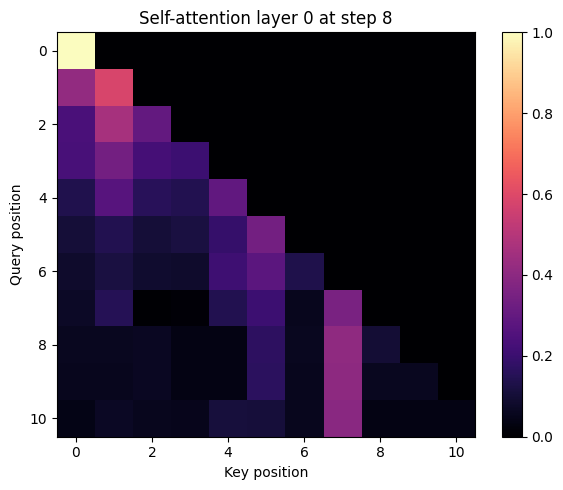

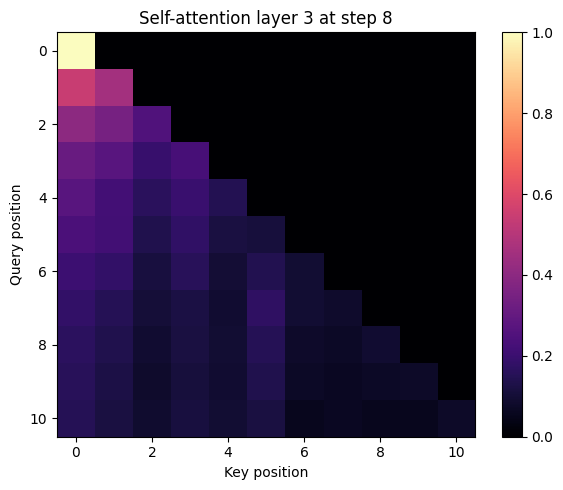

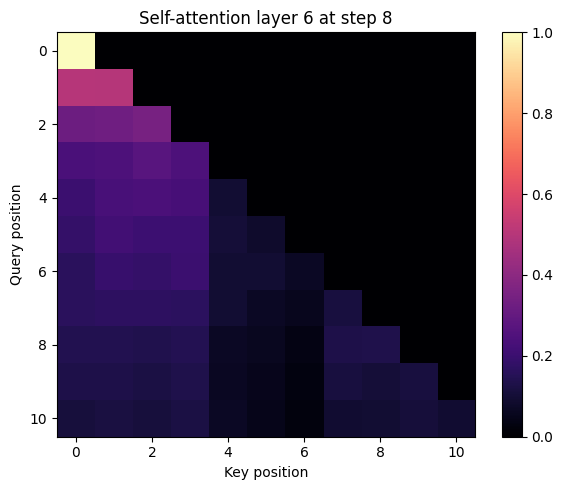

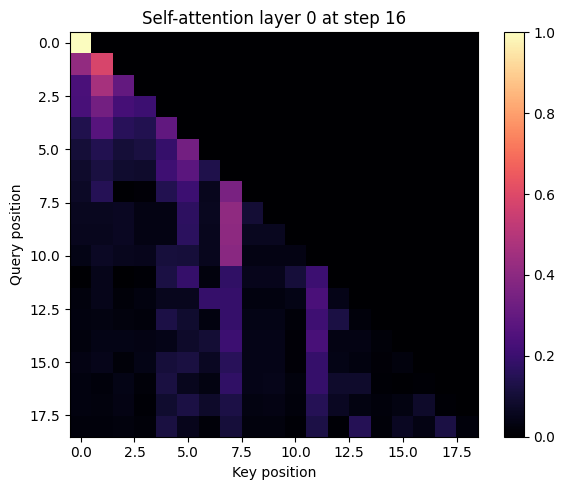

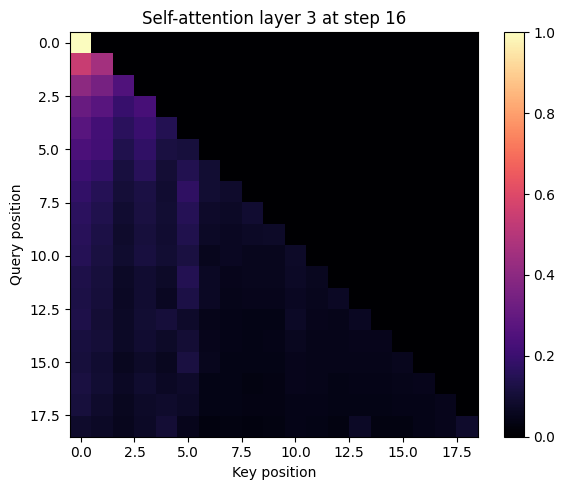

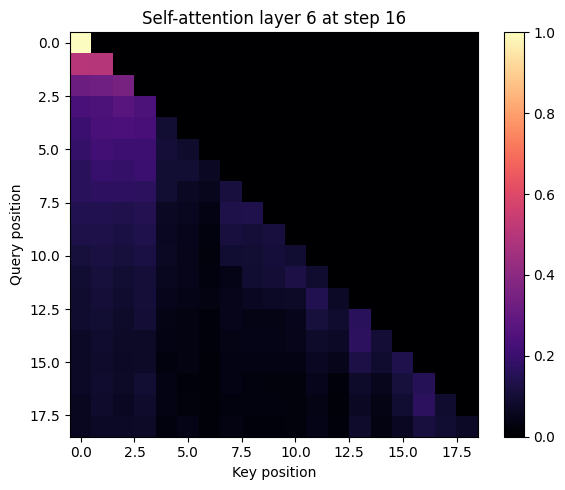

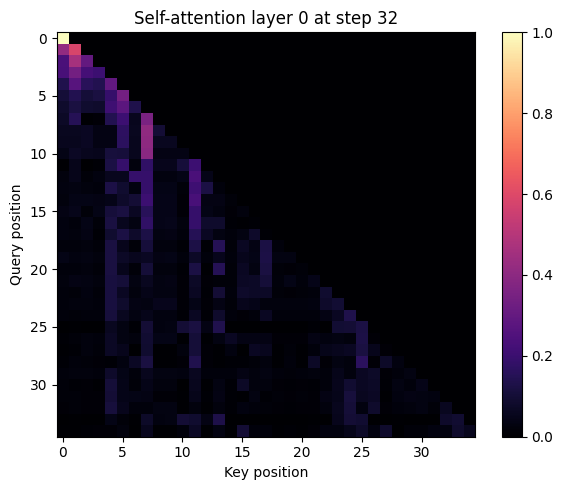

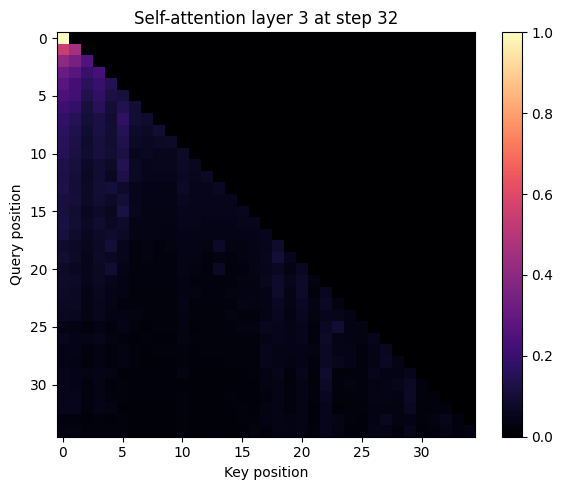

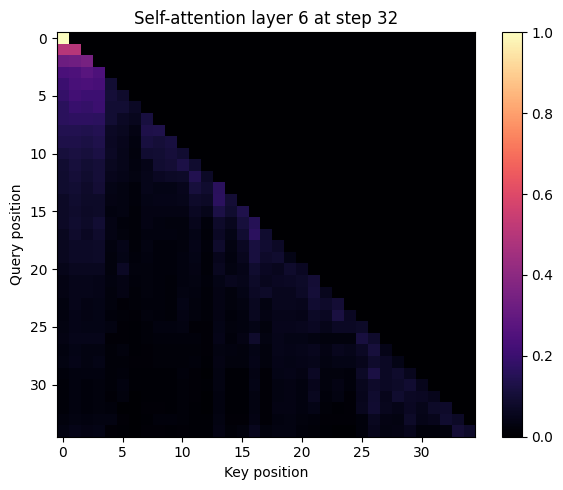

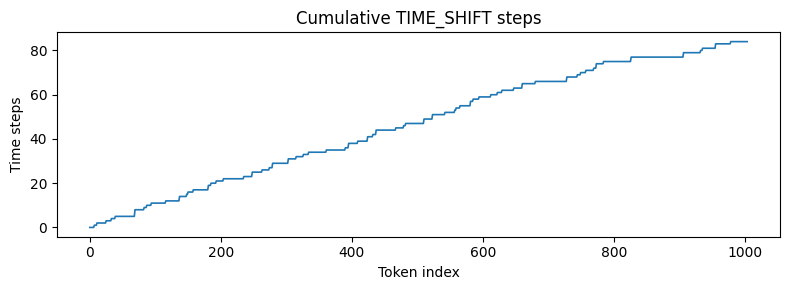

In [53]:
# Visualize internal generation (self-attention + cross-attention) inline
import torch
import matplotlib.pyplot as plt
from IPython.display import Audio, display

from midi_tokenizer import (
    TIME_SHIFT_PREFIX,
    decode_token_ids_to_tokens,
    load_vocab,
    render_token_ids_to_wav,
 )

# Settings
SNAPSHOT_STEPS = [8, 16, 32]
LAYERS_TO_PLOT = [0, 3, 6]
MAX_NEW_TOKENS = 1000
TEMPERATURE = 1.6
TOP_K = 50
DO_SAMPLE = True
SEED_IDS = [0, 1, 2, 3]
STEP_SECONDS = 0.12
PROMPT = "calm and soothing music, with low pitch"
USE_TEXT_CONDITIONING = True

# Load vocab
candidate_vocab_paths = [
    Path("/kaggle/working/data/midi_vocab_fixed.json"),
    Path("data/midi_vocab_fixed.json"),
]
vocab_path = next((p for p in candidate_vocab_paths if p.exists()), None)
if vocab_path is None:
    raise FileNotFoundError(
        "Could not find midi_vocab_fixed.json. Expected at /kaggle/working/data/midi_vocab_fixed.json or data/midi_vocab_fixed.json"
    )
itos = load_vocab(vocab_path)

# Load checkpoint
base_model = model.module if hasattr(model, "module") else model
ckpt_path = Path("/kaggle/input/datasets/bhaskarpandey42/model112/phase2_best_text_conditioned.pt")

if ckpt_path is None:
    raise FileNotFoundError("No checkpoint found for visualization.")
ckpt = torch.load(ckpt_path, map_location=DEVICE)
base_model.load_state_dict(ckpt["model_state_dict"], strict=False)
if "text_encoder_state_dict" in ckpt:
    text_encoder.load_state_dict(ckpt["text_encoder_state_dict"], strict=True)
print(f"Loaded checkpoint: {ckpt_path}")

# Prepare text conditioning inputs
if USE_TEXT_CONDITIONING:
    input_ids, attention_mask = encode_prompt_batch([PROMPT], max_len=MAX_TEXT_LEN)
    text_inputs = {
        "input_ids": input_ids.to(DEVICE),
        "attention_mask": attention_mask.to(DEVICE),
    }
    text_encoder.eval()
    with torch.no_grad():
        context = text_encoder(text_inputs["input_ids"], text_inputs["attention_mask"])
        context_mask = text_inputs["attention_mask"].unsqueeze(1).unsqueeze(1)
else:
    context = None
    context_mask = None

def _top_k_filter(scores: torch.Tensor, top_k: int) -> torch.Tensor:
    if top_k <= 0:
        return scores
    k = min(top_k, scores.size(-1))
    threshold = torch.topk(scores, k=k, dim=-1).values[:, -1].unsqueeze(-1)
    return scores.masked_fill(scores < threshold, float("-inf"))

def _pick_token(scores: torch.Tensor, do_sample: bool) -> torch.Tensor:
    if do_sample:
        probs = torch.softmax(scores, dim=-1)
        return torch.multinomial(probs, num_samples=1)
    return torch.argmax(scores, dim=-1, keepdim=True)

def _show_attention_heatmap(attn: torch.Tensor, title: str) -> None:
    plt.figure(figsize=(6, 5))
    plt.imshow(attn, cmap="magma", aspect="auto")
    plt.title(title)
    plt.xlabel("Key position")
    plt.ylabel("Query position")
    plt.colorbar()
    plt.tight_layout()
    plt.show()

def _show_timeline_plot(time_steps: list[int]) -> None:
    plt.figure(figsize=(8, 3))
    plt.plot(range(len(time_steps)), time_steps, linewidth=1.2)
    plt.title("Cumulative TIME_SHIFT steps")
    plt.xlabel("Token index")
    plt.ylabel("Time steps")
    plt.tight_layout()
    plt.show()

generated_tokens = torch.tensor([SEED_IDS], dtype=torch.long, device=DEVICE)
for step in range(1, MAX_NEW_TOKENS + 1):
    logits = base_model(generated_tokens, context=context, context_mask=context_mask)
    next_scores = logits[:, -1, :] / max(1e-6, TEMPERATURE)
    next_scores = _top_k_filter(next_scores, TOP_K)
    next_token = _pick_token(next_scores, DO_SAMPLE)
    generated_tokens = torch.cat([generated_tokens, next_token], dim=1)

    if step in SNAPSHOT_STEPS:
        for layer_idx in LAYERS_TO_PLOT:
            layer = base_model.decoder.layers[layer_idx]
            self_attn = layer.self_attention.attention_scores.mean(dim=1)[0].detach().cpu()
            _show_attention_heatmap(
                self_attn,
                title=f"Self-attention layer {layer_idx} at step {step}",
            )
            if context is not None and layer.cross_attention is not None:
                cross_attn = layer.cross_attention.attention_scores.mean(dim=1)[0].detach().cpu()
                _show_attention_heatmap(
                    cross_attn,
                    title=f"Cross-attention layer {layer_idx} at step {step}",
                )

token_ids = generated_tokens[0].tolist()
decoded_tokens = decode_token_ids_to_tokens(token_ids, itos)
current_steps = 0
cumulative_steps = []
for token in decoded_tokens:
    if token.startswith(TIME_SHIFT_PREFIX):
        shift = int(token[len(TIME_SHIFT_PREFIX):])
        current_steps += max(0, shift)
    cumulative_steps.append(current_steps)

_show_timeline_plot(cumulative_steps)

wav_path = Path("/kaggle/working/generated_vis_sample.wav")
render_token_ids_to_wav(token_ids, itos, wav_path, step_seconds=STEP_SECONDS)
display(Audio(str(wav_path)))

In [55]:
import time
import torch

def benchmark_generate(model, seed, max_new_tokens, use_cache, context=None, context_mask=None):
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    start = time.perf_counter()

    _ = model.generate(
        seed,
        max_new_tokens=max_new_tokens,
        temperature=1.0,
        do_sample=False,
        top_k=0,
        use_cache=use_cache,
        context=context,
        context_mask=context_mask,
    )

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    end = time.perf_counter()

    total = end - start
    return {
        "use_cache": use_cache,
        "total_sec": total,
        "ms_per_token": 1000.0 * total / max_new_tokens,
        "tokens_per_sec": max_new_tokens / total,
    }

# Example usage:
seed = torch.tensor([[0,1,2,3]], device=DEVICE)
max_new_tokens = 1010

print(benchmark_generate(base_model, seed, max_new_tokens, use_cache=False))
print(benchmark_generate(base_model, seed, max_new_tokens, use_cache=True))

{'use_cache': False, 'total_sec': 27.657252912999866, 'ms_per_token': 27.38341872574244, 'tokens_per_sec': 36.518449723734676}
{'use_cache': True, 'total_sec': 9.405589529999816, 'ms_per_token': 9.312464881187935, 'tokens_per_sec': 107.38295529254505}
